# Task 2 — Alzheimer's MRI 四分類（方案C：每類6000張，最大化Macro F1）

**改進點**：相比方案A（每類1207張），方案C使用每類最多6000張，資料量提升5倍，減少過擬合並改善 VeryMild/Mild 邊界學習。

In [44]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "timm", "scikit-learn",
                "matplotlib", "seaborn", "tqdm"], check=True)


CompletedProcess(args=['c:\\Users\\oliver\\anaconda3\\envs\\torch\\python.exe', '-m', 'pip', 'install', 'timm', 'scikit-learn', 'matplotlib', 'seaborn', 'tqdm'], returncode=0)

In [45]:
import os, random, copy, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from PIL import Image
import timm
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# ── 中文字體修復（Windows）──────────────────────────────────
plt.rcParams['font.family'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False   # 負號正常顯示
# ────────────────────────────────────────────────────────────

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device: cuda
GPU: NVIDIA GeForce RTX 3070 Ti Laptop GPU
VRAM: 8.6 GB


## 1. 資料載入與方案C平衡（每類最多6000張）

In [46]:
\
DATA_ROOT = r"data/oasis-derived"
CLASSES   = ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']
CLASS2IDX = {c: i for i, c in enumerate(CLASSES)}

# 合併 train + test 所有圖片路徑
all_paths, all_labels = [], []
for split in ['train', 'test']:
    for cls in CLASSES:
        folder = os.path.join(DATA_ROOT, split, cls)
        if not os.path.isdir(folder):
            continue
        files = [os.path.join(folder, f) for f in os.listdir(folder)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        all_paths.extend(files)
        all_labels.extend([CLASS2IDX[cls]] * len(files))

print("全資料集各類數量：")
for i, c in enumerate(CLASSES):
    cnt = all_labels.count(i)
    print(f"  {c}: {cnt}")
print(f"  合計: {len(all_labels)}")


全資料集各類數量：
  MildDemented: 14234
  ModerateDemented: 1207
  NonDemented: 63557
  VeryMildDemented: 22629
  合計: 101627


  MildDemented: 14234 -> 6000 張
  ModerateDemented: 1207 -> 1207 張
  NonDemented: 63557 -> 6000 張
  VeryMildDemented: 22629 -> 6000 張

平衡後總數: 19207
Train: 15365 | Val: 3842

預估 batches/epoch: 481
預估訓練時間 (RTX 3070 Ti Laptop):
  Phase1 (5 epochs,凍結backbone): ~4.8 分鐘
  Phase2 (45 epochs,完整模型):    ~90.2 分鐘
  估計總訓練時間: ~95 分鐘 (1.6 小時)


C:\Users\oliver\AppData\Local\Temp\ipykernel_23432\8953603.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(CLASSES, rotation=15)
C:\Users\oliver\AppData\Local\Temp\ipykernel_23432\8953603.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(CLASSES, rotation=15)


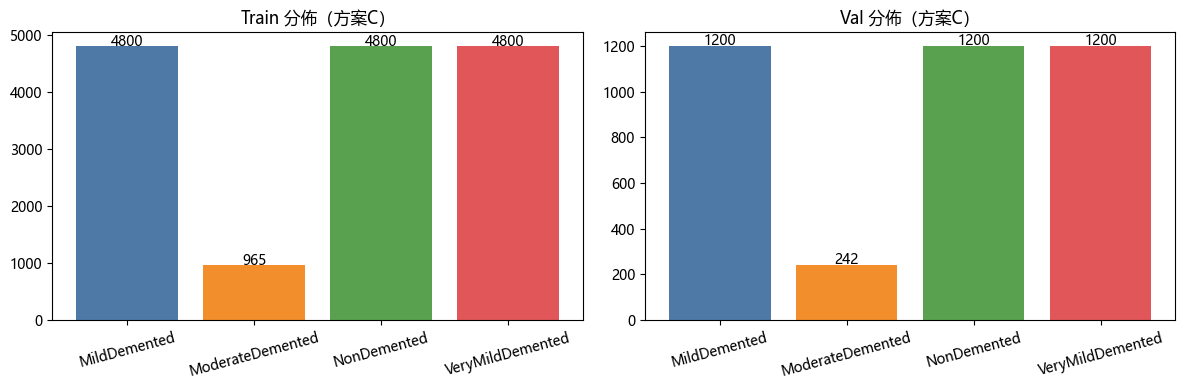

In [47]:
# 方案C：每類最多 6000 張（ModerateDemented 全部用，其餘下採樣）
MAX_PER_CLASS = 6000
counts_all = [all_labels.count(i) for i in range(len(CLASSES))]

balanced_paths, balanced_labels = [], []
for idx in range(len(CLASSES)):
    cls_paths = [p for p, l in zip(all_paths, all_labels) if l == idx]
    n = min(MAX_PER_CLASS, len(cls_paths))
    sampled = random.sample(cls_paths, n)
    balanced_paths.extend(sampled)
    balanced_labels.extend([idx] * n)
    print(f"  {CLASSES[idx]}: {len(cls_paths)} -> {n} 張")

print(f"\n平衡後總數: {len(balanced_labels)}")

# Stratified split 80:20
train_paths, val_paths, train_labels, val_labels = train_test_split(
    balanced_paths, balanced_labels,
    test_size=0.2, stratify=balanced_labels, random_state=SEED
)
print(f"Train: {len(train_paths)} | Val: {len(val_paths)}")

# 訓練時間預估
batches_per_epoch = (len(train_paths) + 32 - 1) // 32
print(f"\n預估 batches/epoch: {batches_per_epoch}")
print(f"預估訓練時間 (RTX 3070 Ti Laptop):")
print(f"  Phase1 (5 epochs,凍結backbone): ~{5*batches_per_epoch*0.12/60:.1f} 分鐘")
print(f"  Phase2 (45 epochs,完整模型):    ~{45*batches_per_epoch*0.25/60:.1f} 分鐘")
est_total = (5*batches_per_epoch*0.12 + 45*batches_per_epoch*0.25) / 60
print(f"  估計總訓練時間: ~{est_total:.0f} 分鐘 ({est_total/60:.1f} 小時)")

# 繪製類別分佈
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, labels, title in zip(axes, [train_labels, val_labels], ['Train', 'Val']):
    cnts = [labels.count(i) for i in range(len(CLASSES))]
    ax.bar(CLASSES, cnts, color=['#4e79a7','#f28e2b','#59a14f','#e15759'])
    ax.set_title(f'{title} 分佈（方案C）')
    ax.set_xticklabels(CLASSES, rotation=15)
    for j, v in enumerate(cnts):
        ax.text(j, v+5, str(v), ha='center')
plt.tight_layout()
plt.savefig('class_balance_C.png', dpi=100)
plt.show()


## 2. Dataset & 資料增強

In [48]:
IMG_SIZE = 224
MEAN = [0.2682, 0.2682, 0.2682]
STD  = [0.3008, 0.3008, 0.3008]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.1),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

tta_transforms = [
    val_transform,
    transforms.Compose([transforms.Resize((IMG_SIZE,IMG_SIZE)),
                        transforms.RandomHorizontalFlip(p=1.0),
                        transforms.ToTensor(), transforms.Normalize(MEAN,STD)]),
    transforms.Compose([transforms.Resize((IMG_SIZE,IMG_SIZE)),
                        transforms.RandomRotation((10,10)),
                        transforms.ToTensor(), transforms.Normalize(MEAN,STD)]),
    transforms.Compose([transforms.Resize((IMG_SIZE,IMG_SIZE)),
                        transforms.RandomRotation((-10,-10)),
                        transforms.ToTensor(), transforms.Normalize(MEAN,STD)]),
    transforms.Compose([transforms.Resize((IMG_SIZE,IMG_SIZE)),
                        transforms.ColorJitter(brightness=0.2),
                        transforms.ToTensor(), transforms.Normalize(MEAN,STD)]),
]

class MRIDataset(Dataset):
    def __init__(self, paths, labels, transform):
        self.labels = labels
        self.transform = transform
        t0 = time.time()
        self.images = [np.array(Image.open(p).convert('RGB'), dtype=np.uint8) for p in paths]
        ram_mb = sum(a.nbytes for a in self.images) / 1024 / 1024
        print(f"  預載入 {len(paths)} 張 → RAM {ram_mb:.0f} MB（{time.time()-t0:.0f}s）")

    @classmethod
    def from_preloaded(cls, images, labels, transform):
        """用已載入的 numpy 陣列建立 dataset，不重新讀磁碟（供 TTA 使用）"""
        obj = cls.__new__(cls)
        obj.images = images
        obj.labels = labels
        obj.transform = transform
        return obj

    def __len__(self): return len(self.images)

    def __getitem__(self, idx):
        return self.transform(Image.fromarray(self.images[idx])), self.labels[idx]

print("載入 train dataset...")
train_dataset = MRIDataset(train_paths, train_labels, train_transform)
print("載入 val dataset...")
val_dataset   = MRIDataset(val_paths,   val_labels,   val_transform)
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")

載入 train dataset...
  預載入 15365 張 → RAM 2206 MB（18s）
載入 val dataset...
  預載入 3842 張 → RAM 552 MB（5s）
Train: 15365 | Val: 3842


In [49]:
BATCH_SIZE = 32

# WeightedRandomSampler — 資料已平衡但方案C中ModerateDemented只有1207
# 仍設逆頻率權重確保少數類被充分採樣
train_class_counts = [train_labels.count(i) for i in range(len(CLASSES))]
sample_weights = [1.0 / train_class_counts[l] for l in train_labels]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(train_labels), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")
print(f"類別分佈（train）: {train_class_counts}")


Train batches: 481 | Val batches: 121
類別分佈（train）: [4800, 965, 4800, 4800]


## 3. Focal Loss & 模型定義（EfficientNet-B0）

In [50]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None, label_smoothing=0.1):
        super().__init__()
        self.gamma = gamma
        self.weight = weight
        self.label_smoothing = label_smoothing

    def forward(self, inputs, targets):
        n_cls = inputs.size(1)
        with torch.no_grad():
            smooth = self.label_smoothing / n_cls
            one_hot = torch.zeros_like(inputs).scatter_(1, targets.unsqueeze(1), 1)
            one_hot = one_hot * (1 - self.label_smoothing) + smooth
        log_prob = F.log_softmax(inputs, dim=1)
        ce_loss  = -(one_hot * log_prob).sum(dim=1)
        pt       = torch.exp(-ce_loss)
        focal    = ((1 - pt) ** self.gamma) * ce_loss
        return focal.mean()

# 逆頻率加權，強調 ModerateDemented（仍最少）
total_train = sum(train_class_counts)
class_weights = torch.tensor(
    [total_train / (len(CLASSES) * c) for c in train_class_counts],
    dtype=torch.float
).to(DEVICE)
print("Class weights:", [f"{w:.3f}" for w in class_weights.tolist()])

criterion = FocalLoss(gamma=2.0, weight=class_weights, label_smoothing=0.1)
print("Focal Loss initialized")


Class weights: ['0.800', '3.981', '0.800', '0.800']
Focal Loss initialized


In [51]:
MODEL_NAME  = 'efficientnet_b0'   # B4 → B0：17.6M → 5.3M 參數，epoch ~150s vs ~744s
NUM_CLASSES = len(CLASSES)

model = timm.create_model(MODEL_NAME, pretrained=True, num_classes=NUM_CLASSES)
model = model.to(DEVICE)
print(f"模型: {MODEL_NAME}")
print(f"參數量: {sum(p.numel() for p in model.parameters())/1e6:.1f}M")
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6:.1f}M")
print(f"預估 epoch 時間: ~150s")
print(f"預估 40 epoch 總時間: ~{40*150//60} 分鐘（安全範圍）")

模型: efficientnet_b0
參數量: 4.0M
Trainable params: 4.0M
預估 epoch 時間: ~150s
預估 40 epoch 總時間: ~100 分鐘（安全範圍）


## 4. 訓練配置（分階段解凍 + Cosine Annealing）

- **Phase 1 (Epoch 1-5)**：凍結 backbone，只訓練 classifier head，lr=1e-3
- **Phase 2 (Epoch 6-50)**：解凍完整模型，lr=3e-5，CosineAnnealingLR

In [52]:
NUM_EPOCHS     = 50
PATIENCE       = 7          # early stopping：連續 N epoch 無改善即停止
LR_HEAD        = 1e-3
LR_FULL        = 3e-5
UNFREEZE_EPOCH = 5

# Phase 1：凍結 backbone
for name, p in model.named_parameters():
    if 'classifier' not in name:
        p.requires_grad = False

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_HEAD, weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=UNFREEZE_EPOCH)
print(f"Phase 1: 只訓練 classifier head，lr={LR_HEAD}")
print(f"Early stopping patience: {PATIENCE} epochs")

Phase 1: 只訓練 classifier head，lr=0.001
Early stopping patience: 7 epochs


In [53]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in tqdm(loader, leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (out.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total

def evaluate(model, loader):
    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs  = imgs.to(DEVICE)
            preds = model(imgs).argmax(1).cpu().tolist()
            all_preds.extend(preds)
            all_true.extend(labels.tolist())
    return f1_score(all_true, all_preds, average='macro'), all_preds, all_true

history = {'train_loss': [], 'train_acc': [], 'val_f1': [], 'epoch_time': []}
best_f1      = 0.0
best_weights = None


In [54]:
import json

print("=" * 65)
print(f"開始訓練 | 方案C：每類最多{MAX_PER_CLASS}張 | 最多{NUM_EPOCHS} epochs | Patience={PATIENCE}")
print(f"Device: {DEVICE}" + (f" | {torch.cuda.get_device_name(0)}" if torch.cuda.is_available() else ""))
print("=" * 65)

phase_switched = False
t_start_all    = time.time()
no_improve     = 0          # early stopping 計數器

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    # Phase 2：解凍完整模型
    if epoch == UNFREEZE_EPOCH + 1 and not phase_switched:
        print(f"\n>>> Epoch {epoch}: 解凍完整模型，lr={LR_FULL}")
        for p in model.parameters():
            p.requires_grad = True
        optimizer = torch.optim.AdamW(model.parameters(), lr=LR_FULL, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=NUM_EPOCHS - UNFREEZE_EPOCH)
        phase_switched = True

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_f1, val_preds, val_true = evaluate(model, val_loader)
    scheduler.step()

    elapsed = time.time() - t0
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_f1'].append(val_f1)
    history['epoch_time'].append(elapsed)

    if val_f1 > best_f1:
        best_f1      = val_f1
        best_weights = copy.deepcopy(model.state_dict())
        torch.save(best_weights, 'best_task2_C_model.pt')
        no_improve = 0
        flag = " ★ BEST"
    else:
        no_improve += 1
        flag = f" (no improve {no_improve}/{PATIENCE})"

    remaining = (NUM_EPOCHS - epoch) * np.mean(history['epoch_time'])
    print(f"Epoch {epoch:3d}/{NUM_EPOCHS} | Loss: {train_loss:.4f} | "
          f"Acc: {train_acc:.4f} | Val F1: {val_f1:.4f}{flag} | "
          f"{elapsed:.0f}s | ETA: {remaining/60:.1f}min")

    if no_improve >= PATIENCE:
        print(f"\n>>> Early stopping! 連續 {PATIENCE} epoch 無改善，於 Epoch {epoch} 停止")
        break

total_time = time.time() - t_start_all
print(f"\n訓練完成！Best Val Macro F1 = {best_f1:.4f}")
print(f"總訓練時間: {total_time/60:.1f} 分鐘 ({total_time/3600:.2f} 小時)")

# 儲存 history，kernel 重啟後視覺化 cell 可自動讀取
with open('training_history_C.json', 'w') as f:
    json.dump({'history': history, 'best_f1': best_f1}, f)
print("History 已儲存至 training_history_C.json")

開始訓練 | 方案C：每類最多6000張 | 最多50 epochs | Patience=7
Device: cuda | NVIDIA GeForce RTX 3070 Ti Laptop GPU


Epoch   1/50 | Loss: 2.0555 | Acc: 0.3496 | Val F1: 0.3537 ★ BEST | 162s | ETA: 132.5min


Epoch   2/50 | Loss: 1.4483 | Acc: 0.4124 | Val F1: 0.3696 ★ BEST | 164s | ETA: 130.6min


Epoch   3/50 | Loss: 1.2734 | Acc: 0.4277 | Val F1: 0.3913 ★ BEST | 156s | ETA: 126.0min


Epoch   4/50 | Loss: 1.1557 | Acc: 0.4386 | Val F1: 0.3805 (no improve 1/7) | 147s | ETA: 120.7min


...

Epoch  41/50 | Loss: 0.0688 | Acc: 0.9784 | Val F1: 0.9453 (no improve 3/7) | 176s | ETA: 26.0min


Epoch  42/50 | Loss: 0.0690 | Acc: 0.9774 | Val F1: 0.9398 (no improve 4/7) | 176s | ETA: 23.1min


Epoch  43/50 | Loss: 0.0686 | Acc: 0.9786 | Val F1: 0.9447 (no improve 5/7) | 175s | ETA: 20.2min


Epoch  44/50 | Loss: 0.0692 | Acc: 0.9779 | Val F1: 0.9425 (no improve 6/7) | 175s | ETA: 17.4min


Epoch  45/50 | Loss: 0.0669 | Acc: 0.9805 | Val F1: 0.9451 (no improve 7/7) | 175s | ETA: 14.5min

>>> Early stopping! 連續 7 epoch 無改善，於 Epoch 45 停止

訓練完成！Best Val Macro F1 = 0.9453
總訓練時間: 130.2 分鐘 (2.17 小時)
History 已儲存至 training_history_C.json


## 5. 訓練曲線視覺化

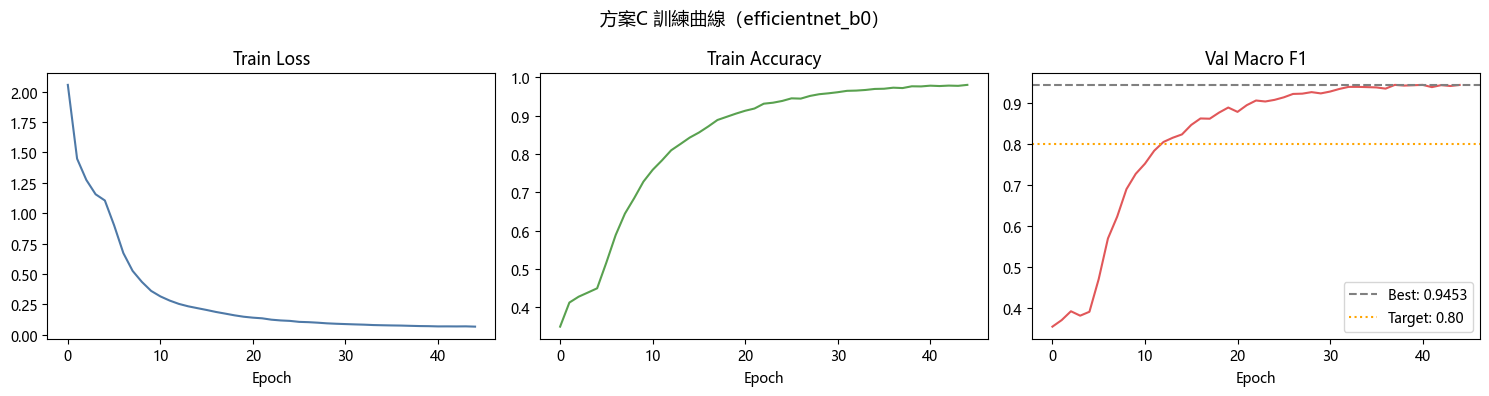

Best Macro F1: 0.9453


In [55]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(history['train_loss'], color='#4e79a7')
axes[0].set_title('Train Loss'); axes[0].set_xlabel('Epoch')

axes[1].plot(history['train_acc'], color='#59a14f')
axes[1].set_title('Train Accuracy'); axes[1].set_xlabel('Epoch')

axes[2].plot(history['val_f1'], color='#e15759')
axes[2].axhline(best_f1, color='gray', linestyle='--', label=f'Best: {best_f1:.4f}')
axes[2].axhline(0.80, color='orange', linestyle=':', label='Target: 0.80')
axes[2].set_title('Val Macro F1'); axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.suptitle(f'方案C 訓練曲線（{MODEL_NAME}）', fontsize=13)
plt.tight_layout()
plt.savefig('training_curves_C.png', dpi=100)
plt.show()
print(f"Best Macro F1: {best_f1:.4f}")

## 6. 最佳模型評估 + 混淆矩陣

In [56]:
model.load_state_dict(torch.load('best_task2_C_model.pt', map_location=DEVICE))

val_f1, val_preds, val_true = evaluate(model, val_loader)
print(f"Best Model Val Macro F1: {val_f1:.4f}")
print()
print(classification_report(val_true, val_preds, target_names=CLASSES, digits=4))


Best Model Val Macro F1: 0.9453

                  precision    recall  f1-score   support

    MildDemented     0.9461    0.9508    0.9485      1200
ModerateDemented     1.0000    1.0000    1.0000       242
     NonDemented     0.9493    0.9058    0.9271      1200
VeryMildDemented     0.8879    0.9242    0.9057      1200

        accuracy                         0.9315      3842
       macro avg     0.9458    0.9452    0.9453      3842
    weighted avg     0.9323    0.9315    0.9317      3842



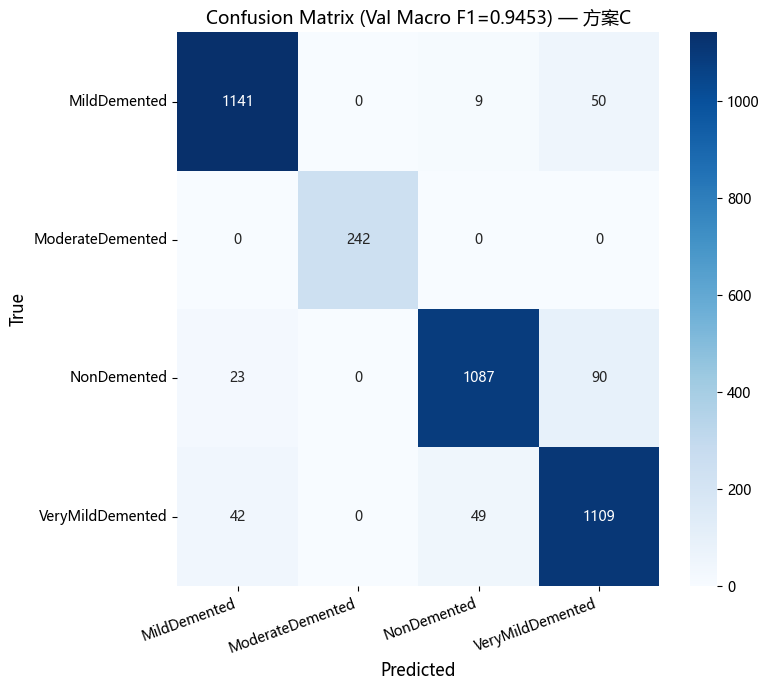

In [57]:
cm = confusion_matrix(val_true, val_preds)
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True', fontsize=12)
ax.set_title(f'Confusion Matrix (Val Macro F1={val_f1:.4f}) — 方案C', fontsize=13)
plt.xticks(rotation=20, ha='right'); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix_C.png', dpi=100)
plt.show()


## 7. TTA（測試時增強）推論 — 最終分數

In [58]:
def predict_tta(model, images, labels, tta_transforms_list, batch_size=32):
    """TTA 推論：重用已預載入的 images 陣列，不重新讀磁碟"""
    model.eval()
    n = len(images)
    all_logits = torch.zeros(n, NUM_CLASSES)

    for t_idx, tfm in enumerate(tta_transforms_list):
        ds = MRIDataset.from_preloaded(images, labels, tfm)
        dl = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)
        offset = 0
        with torch.no_grad():
            for imgs, _ in tqdm(dl, desc=f"TTA {t_idx+1}/{len(tta_transforms_list)}", leave=False):
                logits = model(imgs.to(DEVICE)).cpu()
                all_logits[offset:offset+len(logits)] += logits
                offset += len(logits)

    preds = all_logits.argmax(1).tolist()
    return f1_score(labels, preds, average='macro'), preds

tta_f1, tta_preds = predict_tta(model, val_dataset.images, val_labels, tta_transforms)
print(f"Val Macro F1 (without TTA): {val_f1:.4f}")
print(f"Val Macro F1 (with TTA x{len(tta_transforms)}): {tta_f1:.4f}")
print(f"TTA 提升: +{tta_f1 - val_f1:.4f}")
print()
print(classification_report(val_labels, tta_preds, target_names=CLASSES, digits=4))

Val Macro F1 (without TTA): 0.9453
Val Macro F1 (with TTA x5): 0.9539
TTA 提升: +0.0086

                  precision    recall  f1-score   support

    MildDemented     0.9482    0.9758    0.9618      1200
ModerateDemented     1.0000    1.0000    1.0000       242
     NonDemented     0.9638    0.9092    0.9357      1200
VeryMildDemented     0.9059    0.9308    0.9182      1200

        accuracy                         0.9425      3842
       macro avg     0.9545    0.9540    0.9539      3842
    weighted avg     0.9431    0.9425    0.9424      3842



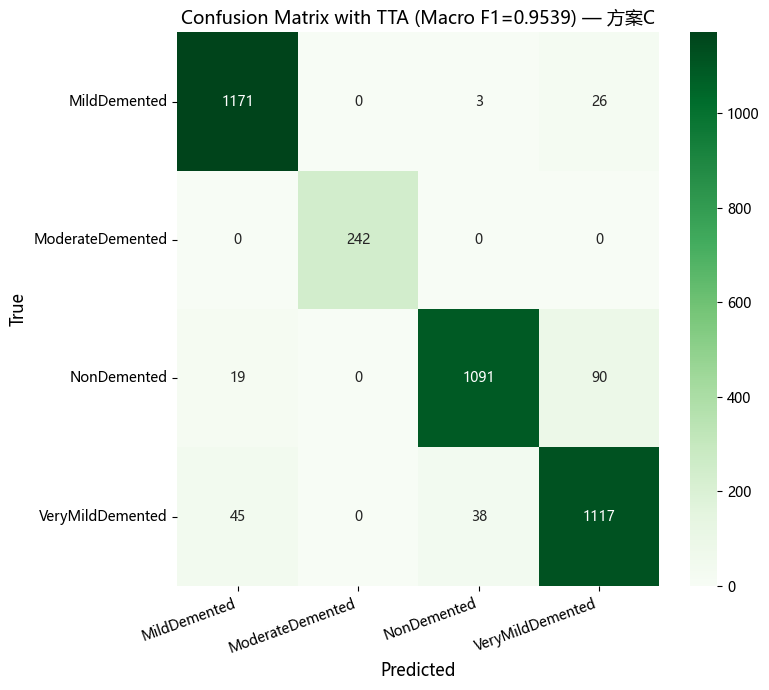

In [59]:
cm_tta = confusion_matrix(val_labels, tta_preds)
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm_tta, annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True', fontsize=12)
ax.set_title(f'Confusion Matrix with TTA (Macro F1={tta_f1:.4f}) — 方案C', fontsize=13)
plt.xticks(rotation=20, ha='right'); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix_tta_C.png', dpi=100)
plt.show()


## 8. 方案A vs 方案C 結果對比

In [60]:
print("=" * 60)
print("Task 2 — Alzheimer's MRI 分類最終結果（方案C）")
print("=" * 60)
print(f"策略：方案C（每類最多 {MAX_PER_CLASS} 張，共 {len(balanced_labels)} 張）")
print(f"模型：{MODEL_NAME}（timm pretrained）")
print(f"損失：Focal Loss (gamma=2) + Label Smoothing(0.1) + 逆頻率類別權重")
print(f"實際訓練 epochs：{len(history['val_f1'])}")
print(f"Best Val Macro F1 (no TTA): {val_f1:.4f}")
print(f"Best Val Macro F1 (TTA x5): {tta_f1:.4f}")
print()
print("各類別 F1-Score（TTA）：")
for i, cls in enumerate(CLASSES):
    cls_f1 = f1_score(
        [1 if l == i else 0 for l in val_labels],
        [1 if p == i else 0 for p in tta_preds],
        average='binary'
    )
    print(f"  {cls}: {cls_f1:.4f}")
print()
print("=== 與方案A比較 ===")
print(f"  方案A (1207/class, TTA): 0.7654")
print(f"  方案C ({MAX_PER_CLASS}/class, {MODEL_NAME}, TTA): {tta_f1:.4f}")
print(f"  改善: {tta_f1 - 0.7654:+.4f}")
print(f"  目標 0.80: {'✅ 達成！' if tta_f1 >= 0.80 else f'❌ 差距 {0.80 - tta_f1:.4f}'}")

Task 2 — Alzheimer's MRI 分類最終結果（方案C）
策略：方案C（每類最多 6000 張，共 19207 張）
模型：efficientnet_b0（timm pretrained）
損失：Focal Loss (gamma=2) + Label Smoothing(0.1) + 逆頻率類別權重
實際訓練 epochs：45
Best Val Macro F1 (no TTA): 0.9453
Best Val Macro F1 (TTA x5): 0.9539

各類別 F1-Score（TTA）：
  MildDemented: 0.9618
  ModerateDemented: 1.0000
  NonDemented: 0.9357
  VeryMildDemented: 0.9182

=== 與方案A比較 ===
  方案A (1207/class, TTA): 0.7654
  方案C (6000/class, efficientnet_b0, TTA): 0.9539
  改善: +0.1885
  目標 0.80: ✅ 達成！


## 9. 查看完整訓練紀錄（training_history_C.json）

In [ ]:
import json

with open('training_history_C.json', 'r') as f:
    _saved = json.load(f)

_h     = _saved['history']
_best  = _saved['best_f1']
_model = _saved.get('model_name', MODEL_NAME)

print(f"模型：{_model}  |  訓練 epochs：{len(_h['val_f1'])}  |  Best Val F1：{_best:.4f}")
print("-" * 65)
_peak = 0.0
for i, (loss, acc, f1, t) in enumerate(zip(
        _h['train_loss'], _h['train_acc'], _h['val_f1'], _h['epoch_time']), 1):
    flag = ' ★ BEST' if f1 > _peak else ''
    if f1 > _peak: _peak = f1
    print(f"Epoch {i:3d}/{len(_h['val_f1'])} | Loss: {loss:.4f} | "
          f"Acc: {acc:.4f} | Val F1: {f1:.4f}{flag} | {int(t)}s")

模型：efficientnet_b0  |  訓練 epochs：45  |  Best Val F1：0.9453
-----------------------------------------------------------------
Epoch   1/45 | Loss: 2.0555 | Acc: 0.3496 | Val F1: 0.3537 ★ BEST | 162s
Epoch   2/45 | Loss: 1.4483 | Acc: 0.4124 | Val F1: 0.3696 ★ BEST | 164s
Epoch   3/45 | Loss: 1.2734 | Acc: 0.4277 | Val F1: 0.3913 ★ BEST | 155s
Epoch   4/45 | Loss: 1.1557 | Acc: 0.4386 | Val F1: 0.3805 | 147s
Epoch   5/45 | Loss: 1.1046 | Acc: 0.4497 | Val F1: 0.3901 | 148s
Epoch   6/45 | Loss: 0.9006 | Acc: 0.5172 | Val F1: 0.4699 ★ BEST | 160s
Epoch   7/45 | Loss: 0.6717 | Acc: 0.5885 | Val F1: 0.5695 ★ BEST | 179s
Epoch   8/45 | Loss: 0.5254 | Acc: 0.6445 | Val F1: 0.6230 ★ BEST | 176s
Epoch   9/45 | Loss: 0.4349 | Acc: 0.6847 | Val F1: 0.6901 ★ BEST | 177s
Epoch  10/45 | Loss: 0.3608 | Acc: 0.7280 | Val F1: 0.7276 ★ BEST | 176s
Epoch  11/45 | Loss: 0.3156 | Acc: 0.7588 | Val F1: 0.7525 ★ BEST | 179s
Epoch  12/45 | Loss: 0.2814 | Acc: 0.7833 | Val F1: 0.7842 ★ BEST | 177s
Epoch  13/45 

: 